# NN(Neural network model) : Multi-layer perceptron (MLP)
> * I try Neural network model "multi-layer Perceptron classifier".
> * This is the advanced models of Deep Learning.
> * I hope this will help you.Please excuse if there are any mistakes🙏

In [1]:
import numpy as np 
import pandas as pd 

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/tabular-playground-series-nov-2021/sample_submission.csv
/kaggle/input/tabular-playground-series-nov-2021/train.csv
/kaggle/input/tabular-playground-series-nov-2021/test.csv


In [2]:
# faster downloading
import datatable as dt
train = dt.fread(r'/kaggle/input/tabular-playground-series-nov-2021/train.csv').to_pandas()
test = dt.fread(r'/kaggle/input/tabular-playground-series-nov-2021/test.csv').to_pandas()

In [3]:
# Reduce memory usage if PC is 
# train features
for col in train.columns:
    if train[col].dtype == "float64":
        train[col]=pd.to_numeric(train[col], downcast="float")
    if train[col].dtype == "int64":
        train[col]=pd.to_numeric(train[col], downcast="integer")
    

# test features
for col in test.columns:
    if test[col].dtype == "float64":
        test[col]=pd.to_numeric(test[col], downcast="float")
    if train[col].dtype == "int64":
        test[col]=pd.to_numeric(test[col], downcast="integer")  

In [4]:
id = test['id'].copy()
train = train.drop('id' ,axis = 1)
test = test.drop('id', axis = 1)

In [5]:
X = train.drop('target', axis = 1).copy()
y = train['target'].copy()
X_test = test.copy()

del train
del test

---------------


# improved tips💡
> * This is basic model. so you may
> * add parameters like this -> (max_iter = 1000, hidden_layer_sizes = (10, 10), alpha = 0.0001, solver = 'adam', random_state = 42)
> * using scaler, adding or choosing feature, more folds, random_state etc...Good luck!

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold

from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_curve, auc

In [7]:
import time
start = time.perf_counter()
print("--------⏱start-----------")

--------⏱start-----------


In [8]:
splits = 5
seed = 42
skf = StratifiedKFold(n_splits = splits, shuffle=True, random_state=seed)

scores = []
pred= []

for fold, (idx_train, idx_valid) in enumerate(skf.split(X, y)):
    
    X_train, y_train = X.iloc[idx_train], y.iloc[idx_train]
    X_valid, y_valid = X.iloc[idx_valid], y.iloc[idx_valid]

    model = MLPClassifier()
    model.fit(X_train, y_train)
    
    pred_valid = model.predict_proba(X_valid)[:,1]
    fpr, tpr, _ = roc_curve(y_valid, pred_valid)
    score = auc(fpr, tpr)
    scores.append(score)

    test_preds = model.predict_proba(X_test)[:,1]
    pred.append(test_preds)
    print("fold :  ",fold, " MLPsore : ", score)

fold :   0  MLPsore :  0.7488809711202523
fold :   1  MLPsore :  0.7497350002756329
fold :   2  MLPsore :  0.7507847225502653
fold :   3  MLPsore :  0.751296271279155
fold :   4  MLPsore :  0.7537207457125578


In [9]:
p_1 = sum(scores)/splits
print(p_1)
print(scores)

0.7508835421875727
[0.7488809711202523, 0.7497350002756329, 0.7507847225502653, 0.751296271279155, 0.7537207457125578]


In [10]:
time_end = time.perf_counter()
process_time = time_end - start
print("process_time:{0}".format(process_time) )

process_time:5217.630207769001


In [11]:
predictions = np.mean(np.column_stack(pred) ,axis = 1)
submission = pd.DataFrame({'id' : id, 'target' : predictions})
submission.to_csv("submission.csv", index = False)

submission.head()

,id,target
0,600000,0.765077
1,600001,0.752088
2,600002,0.745932
3,600003,0.342553
4,600004,0.702735


Text(0.5, 1.0, 'MLPClassifier ')

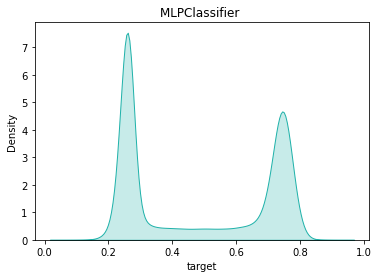

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

sns.kdeplot(submission['target'],fill=True, color = "#20B2AA")
plt.title('MLPClassifier ')